In [1]:
# ============================================================
# 1. IMPORTAÇÕES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


In [2]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================
# Baixe os arquivos em: https://www.kaggle.com/competitions/spaceship-titanic/data
# Coloque train.csv e test.csv na mesma pasta deste script.

train_df = pd.read_csv('dataset/train.csv')
test_df  = pd.read_csv("dataset/test.csv")

In [3]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Cabin → Deck, Num, Side ---
    cabin = df["Cabin"].str.split("/", expand=True)
    df["CabinDeck"] = cabin[0]
    df["CabinNum"]  = pd.to_numeric(cabin[1], errors="coerce")
    df["CabinSide"] = cabin[2]
    df.drop(columns=["Cabin"], inplace=True)

    # --- PassengerId → Group ---
    df["Group"] = df["PassengerId"].str.split("_").str[0].astype(int)
    df["GroupSize"] = df.groupby("Group")["Group"].transform("count")
    df.drop(columns=["PassengerId"], inplace=True)

    # --- Nome → não agrega muito, remover ---
    df.drop(columns=["Name"], inplace=True, errors="ignore")

    # --- Total gasto ---
    amenity_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[amenity_cols].sum(axis=1)

    # --- Log-transform das amenidades (reduz skewness) ---
    for col in amenity_cols + ["TotalSpend"]:
        df[col] = np.log1p(df[col])

    # --- CryoSleep como bool → int ---
    df["CryoSleep"] = df["CryoSleep"].map({True: 1, False: 0, "True": 1, "False": 0})
    df["VIP"]       = df["VIP"].map({True: 1, False: 0, "True": 1, "False": 0})

    return df


train_eng = feature_engineering(train_df)
test_eng  = feature_engineering(test_df)

TARGET = "Transported"
X = train_eng.drop(columns=[TARGET])
y = train_eng[TARGET].astype(int)

print("\nFeatures após engenharia:", X.columns.tolist())


Features após engenharia: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinDeck', 'CabinNum', 'CabinSide', 'Group', 'GroupSize', 'TotalSpend']


In [4]:
# ============================================================
# 4. PRÉ-PROCESSAMENTO COM PIPELINE (ColumnTransformer)
# ============================================================

# Identificar colunas numéricas e categóricas automaticamente
num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNuméricas ({len(num_features)}): {num_features}")
print(f"Categóricas ({len(cat_features)}): {cat_features}")

# Pipeline para numéricas: impute mediana → escala
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Pipeline para categóricas: impute moda → ordinal encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
])


Numéricas (12): ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'Group', 'GroupSize', 'TotalSpend']
Categóricas (4): ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']


In [5]:
# ============================================================
# 5. TREINAMENTO E VALIDAÇÃO CRUZADA
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print("\n--- Validação Cruzada (5-fold) ---")
cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  CV acc = {scores.mean():.4f} ± {scores.std():.4f}")


--- Validação Cruzada (5-fold) ---


Logistic Regression        CV acc = 0.7712 ± 0.0068
Random Forest              CV acc = 0.7984 ± 0.0065
Gradient Boosting          CV acc = 0.8043 ± 0.0057


In [6]:
# ============================================================
# 6. AJUSTE DE HIPERPARÂMETROS — Random Forest (GridSearchCV)
# ============================================================
print("\n--- GridSearchCV: Random Forest ---")

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(random_state=42)),
])

param_grid = {
    "clf__n_estimators"    : [200, 400],
    "clf__max_depth"       : [None, 15, 25],
    "clf__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros : {grid_search.best_params_}")
print(f"Melhor CV accuracy  : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
val_acc = accuracy_score(y_val, best_model.predict(X_val))
print(f"Accuracy no val set : {val_acc:.4f}")


--- GridSearchCV: Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parâmetros : {'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}
Melhor CV accuracy  : 0.8010
Accuracy no val set : 0.7993


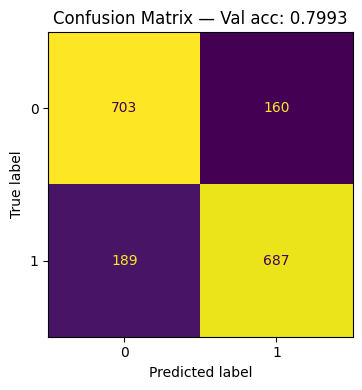

Confusion matrix salvo em confusion_matrix.png


In [7]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — Val acc: {val_acc:.4f}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()
print("Confusion matrix salvo em confusion_matrix.png")


In [8]:
# Relatório de classificação
print("\nRelatório de Classificação (val):")
print(classification_report(y_val, best_model.predict(X_val),
                             target_names=["Not Transported", "Transported"]))


Relatório de Classificação (val):
                 precision    recall  f1-score   support

Not Transported       0.79      0.81      0.80       863
    Transported       0.81      0.78      0.80       876

       accuracy                           0.80      1739
      macro avg       0.80      0.80      0.80      1739
   weighted avg       0.80      0.80      0.80      1739



In [10]:
# ============================================================
# 8. GERAÇÃO DO ARQUIVO DE SUBMISSÃO
# ============================================================

# Treinar com todos os dados de treino
best_model.fit(X, y)

test_ids    = test_df["PassengerId"]
predictions = best_model.predict(test_eng).astype(bool)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": predictions,
})

submission.to_csv("submission.csv", index=False)
print("\nArquivo submission.csv gerado!")


Arquivo submission.csv gerado!
